In [30]:
import pickle
from pathlib import Path
import glob

# Get the most recent dd_metrics.pkl file.
filenames = glob.glob("logs/*/*/*/*/dd_metrics.pkl")
filenames = sorted(filenames, key=lambda x: Path(x).stat().st_mtime)
filename = filenames[-1]

with open(filename, "rb") as f:
    metrics = pickle.load(f)
print(filename)

logs/noname/RotatedTinyMNIST_0.0/EWC_ADWIN_MLP/20260526-181404/dd_metrics.pkl


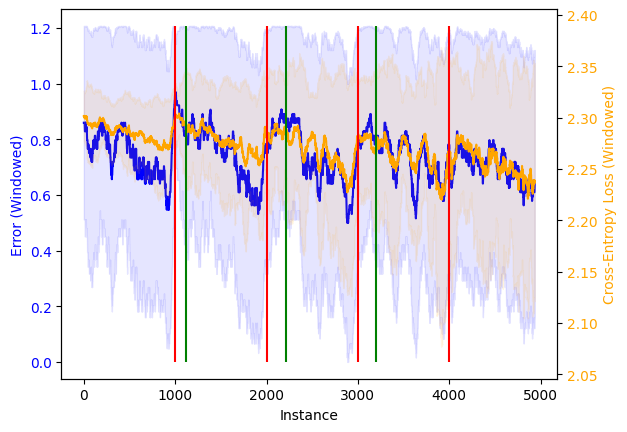

In [31]:
import matplotlib.pyplot as plt
import numpy as np


# Windowed mean
window_size = 64


def calculate_stream_statistics(window_size: int, data: np.ndarray):
    # Create the kernel for the moving average
    kernel = np.ones(window_size) / window_size

    # Calculate moving mean (valid mode returns only full-window overlaps)
    mean = np.convolve(data, kernel, mode="valid")

    # Calculate moving mean of squares
    mean_sq = np.convolve(data**2, kernel, mode="valid")

    # Calculate moving standard deviation
    # np.maximum is used to prevent negative values due to floating point errors
    std = np.sqrt(np.maximum(mean_sq - mean**2, 0))

    # Define x-axis based on the valid convolution output length
    x = np.arange(len(mean))

    return mean, std, x


ce_stream = metrics["ce_stream"]
ce_stream_avg, ce_stream_std, ce_stream_x = calculate_stream_statistics(
    window_size, ce_stream
)
error_stream = metrics["error_stream"]
error_stream_avg, error_stream_std, error_stream_x = calculate_stream_statistics(
    window_size, error_stream
)

# x = np.linspace(0, len(ce_stream), len(error_stream_avg))

# Plot both the Error stream and the CE loss stream with different y-axes.
fig, ax1 = plt.subplots()
ax1.set_xlabel("Instance")
ax1.set_ylabel("Error (Windowed)", color="blue")
ax1.plot(error_stream_x, error_stream_avg, color="blue")
ax1.fill_between(
    error_stream_x,
    np.array(error_stream_avg) - np.array(error_stream_std),
    np.array(error_stream_avg) + np.array(error_stream_std),
    color="blue",
    alpha=0.1,
)
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Cross-Entropy Loss (Windowed)", color="orange")
ax2.plot(ce_stream_x, ce_stream_avg, color="orange")
ax2.fill_between(
    ce_stream_x,
    np.array(ce_stream_avg) - np.array(ce_stream_std),
    np.array(ce_stream_avg) + np.array(ce_stream_std),
    color="orange",
    alpha=0.1,
)
ax2.tick_params(axis="y", labelcolor="orange")


ymin, ymax = plt.ylim()

plt.vlines(metrics["trues"], ymin, ymax, colors="red", label="true drift")
plt.vlines(metrics["preds"], ymin, ymax, colors="green", label="detected drift")

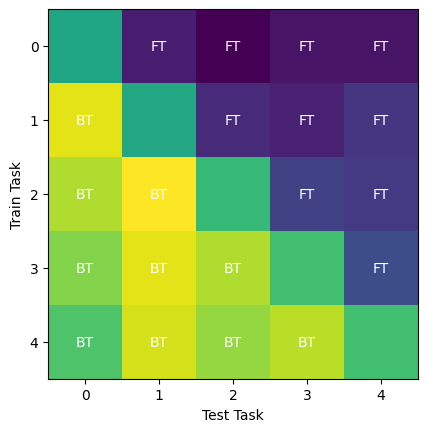

In [32]:
with (Path(filename).parent / "ocl_metrics.pkl").open("rb") as f:
    ocl_metrics = pickle.load(f)

plt.imshow(ocl_metrics.accuracy_matrix, aspect="equal", cmap="viridis")
plt.ylabel("Train Task")
plt.xlabel("Test Task")

# Label Above the diagonal as "Forward Transfer", Below the diagonal as "Backward Transfer", Diagonal as "Retention"
for i in range(ocl_metrics.accuracy_matrix.shape[0]):
    for j in range(ocl_metrics.accuracy_matrix.shape[1]):
        if i < j:
            plt.text(j, i, "FT", ha="center", va="center", color="white")
        elif i > j:
            plt.text(j, i, "BT", ha="center", va="center", color="white")
        # else:
        # plt.text(j, i, "R", ha="center", va="center", color="white")